# 02 · Zonas de velocidad y área de la zona de transición (descompresión)

En esta descarga intermitente hay **tres regímenes de velocidad**:
- **ESTÁTICO** — las bolitas están quietas.
- **TRANSICIÓN / descompresión** — recién empiezan a moverse "un poquito": más rápido que
  estático pero todavía sin caer.
- **CAÍDA** — ya cayendo rápido.

**Meta (pregunta del director): medir el ÁREA de la zona de transición.**

La velocidad de transición es un **rango**, y lo sacamos de los propios datos, sin ventanas de
búsqueda elegidas a mano (ver §2): dos valles en la distribución de velocidades — el que separa
estático de móvil, y el que separa la fase lenta de la caída rápida dentro de lo móvil — delimitan
el rango de transición.

Nota: sólo seguimos las bolitas **blancas** (trazadoras) dentro del hidrogel transparente, así que
NO se puede medir densidad/empaquetamiento — trabajamos con velocidad. Calibración FIJI: 14 px = 1 cm.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from matplotlib.colors import ListedColormap

FPS  = 80
PXMM = 1.4               # 14 px = 1 cm
k    = FPS / PXMM        # px/frame -> mm/s

OUTDIR = '../outputs/nb02'          # salidas de ESTE notebook, para no ensuciar outputs/
os.makedirs(OUTDIR, exist_ok=True)

def local_extrema(y):
    """Indices de maximos/minimos locales de y, por cambio de signo de la derivada.
    Sin ventanas ni rangos impuestos -- encuentra lo que hay, donde este. Se usa en
    seccion 1 (V_CUT) y seccion 2 (umbrales estatico/movil/transicion/caida)."""
    d = np.sign(np.diff(y))
    idx = np.where(np.diff(d) != 0)[0] + 1
    kinds = ['max' if d[i - 1] > 0 else 'min' for i in idx]
    return idx, kinds

t = pd.read_pickle('../outputs/t_velocities.pkl')
print('muestras:', len(t), '| particulas:', t.particle.nunique(), f'| factor x{k:.1f} px/f->mm/s')

muestras: 1765517 | particulas: 2069 | factor x57.1 px/f->mm/s


## 0. Control de calidad del tracking (QC)

Antes de medir velocidades, primero **miramos** el tracking crudo (0.1): una animación de las
bolitas cayendo, **sin etiquetar nada**, sólo para ver con los ojos si algo se comporta raro. Lo que
saltó a la vista ahí —bolitas que parecen "duplicarse" y ráfagas de movimiento cerca del final— es
lo que motiva las preguntas que respondemos con datos a continuación:

1. **¿Cómo evoluciona la descarga en el tiempo?** — ¿el silo se vacía?, ¿hasta cuándo hay
   suficientes bolitas para hacer estadística? (0.2)
2. **¿Son confiables las detecciones y el linkeo?** — ¿las bolitas "saltan" (mislinks), o el tracking
   es sano? ¿de dónde sale la "duplicación"? (0.3)
3. **Las ráfagas de movimiento del final, ¿son reales o un artefacto?** (0.4)
4. **¿Se conserva la cantidad de bolitas?** — chequeo más estricto que 0.2/0.3: ¿aparecen o
   desaparecen bolitas en el medio del canal? ¿es un problema del video o tracking normal? (0.5–0.6)

De ahí salen **dos señales de confianza independientes** que quedan disponibles para el resto del
notebook — `frame_ok` (población suficiente) y `frag_ok` (tasa de fragmentación normal) — más una
región espacial marcada `in_hotspot` (0.7).

### 0.1 Preview del tracking — mirar antes de medir

Primero lo más simple: **ver** las bolitas moverse. Cada punto es una detección; **no etiquetamos
nada** (ni estático, ni caída) — sólo queremos comprobar a ojo que el tracking sigue bolitas reales
y detectar cualquier cosa rara antes de confiar en los números.

Para eso definimos `render_particle_movie(...)`, una **función reutilizable** que renderiza un mp4
de las posiciones frame a frame (la volvemos a usar más adelante). Acepta una columna opcional para
colorear y un gancho `bg` para, en el futuro, dibujar el video real detrás de los puntos y validar
contra la realidad.

In [2]:
from matplotlib.animation import FuncAnimation
from IPython.display import Video

def render_particle_movie(df, frames=None, step=4, color=None, cmap='viridis', clim=None,
                          s=12, c='#222222', alpha=.8, bg=None, figsize=(5, 9),
                          out=None, outdir='.', capture_fps=None, fps=25, dpi=80, title=''):
    """Renderiza un mp4 de las bolitas trackeadas, frame a frame. REUTILIZABLE (sin globals).

    df           : tabla con columnas 'x','y','frame' (y, opcional, la columna `color`).
    frames       : frames a animar (default: 0..max submuestreado de a `step`).
    color        : nombre de columna para colorear los puntos (default: color plano `c`, SIN etiquetar).
    clim         : (min,max) para la escala de color, si se usa `color`.
    bg           : funcion frame->imagen 2D para dibujar el video real detras (gancho a futuro; default None).
    out          : ruta del mp4 (default: outdir/movie.mp4).
    outdir       : carpeta de salida si no se pasa `out` explicito.
    capture_fps  : fps del video original, sólo para mostrar t=frame/capture_fps en el titulo (opcional).
    fps          : fps de RENDER del mp4 (nada que ver con capture_fps).
    Devuelve un IPython.display.Video embebido.
    """
    out = out or f'{outdir}/movie.mp4'
    if frames is None:
        frames = range(0, int(df['frame'].max()) + 1, step)
    frames = list(frames)
    by   = dict(tuple(df.groupby('frame')))
    xlim = (df.x.min() - 10, df.x.max() + 10)
    ylim = (df.y.max() + 10, df.y.min() - 10)                  # y invertido (coords de imagen)

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_aspect('equal')
    ax.set_xlabel('x [px]'); ax.set_ylabel('y [px]')
    imbg = ax.imshow(bg(frames[0]), cmap='gray', extent=[xlim[0], xlim[1], ylim[0], ylim[1]], zorder=0) if bg else None
    if color is not None:
        sc = ax.scatter([], [], s=s, cmap=cmap, alpha=alpha, edgecolors='none', zorder=2)
        if clim: sc.set_clim(*clim)
    else:
        sc = ax.scatter([], [], s=s, c=c, alpha=alpha, edgecolors='none', zorder=2)
    ttl = ax.set_title(title)

    def upd(i):
        fr = frames[i]; d = by.get(fr)
        sc.set_offsets(d[['x', 'y']].values if d is not None else np.empty((0, 2)))
        if color is not None and d is not None: sc.set_array(d[color].values)
        if bg is not None: imbg.set_data(bg(fr))
        n = 0 if d is None else len(d)
        tstr = f' | t={fr/capture_fps:.1f}s' if capture_fps else ''
        ttl.set_text(f'{title}\nframe {fr}{tstr} | N={n}')

    FuncAnimation(fig, upd, frames=len(frames), interval=1000/fps, blit=False).save(
        out, writer='ffmpeg', fps=fps, dpi=dpi)
    plt.close(fig)
    return Video(out, embed=True)

# preview crudo de TODA la descarga, sin etiquetar (1 de cada 4 frames para que el mp4 sea liviano)
render_particle_movie(t, step=4, out=f'{OUTDIR}/tracking_preview.mp4', capture_fps=FPS,
                      title='Preview del tracking (crudo, sin etiquetar)')

### 0.2 La descarga en el tiempo — el silo se vacía

Contamos cuántas bolitas trazadoras se ven en cada frame. Si el silo se descarga, ese número debe
**bajar** con el tiempo. Eje x en **frames** (video a 80 fps → `t = frame/80`, total ≈ 92 s).

Lo importante para el análisis: cuando quedan **muy pocas** bolitas, cualquier promedio espacial
(por ejemplo un área) se apoya en un puñado de puntos y deja de ser confiable. Definimos
`N_MIN = 50`: por debajo de eso quedan del orden de **~5 bolitas móviles por frame**, insuficientes
para delimitar una zona. Esos frames (~el último 10 % del video) **no se borran** — se **marcan**
como baja confianza y se excluyen sólo de las métricas cuantitativas por-frame.

llenado inicial: 346 bolitas/frame  ->  final: 6   (el silo se vacia)
N < 50 desde el frame 6602 (t = 83 s): quedan 49 bolitas = 14% del material
frames marcados baja-confianza: 711 de 7384 (10%) | mediana de MOVILES/frame ahi: 5


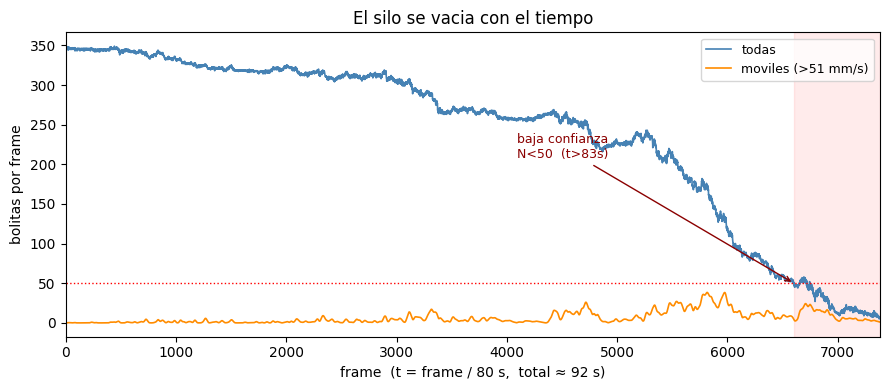

In [3]:
N_MIN = 50                                 # min bolitas/frame para confiar en una estadistica espacial
V_MOV = 51                                 # mm/s, umbral estatico/movil (se re-deriva formal en la sec. 1)

ppf   = t.groupby('frame').size()          # bolitas por frame
mov0  = t[t['v'] * k > V_MOV]
mpf   = mov0.groupby('frame').size().reindex(ppf.index, fill_value=0)   # bolitas MOVILES por frame
fmax  = int(t.frame.max())
n0    = ppf.iloc[:100].median()            # llenado inicial
low   = ppf.index[ppf < N_MIN]
f_low = int(low.min()) if len(low) else fmax
frame_ok = (ppf >= N_MIN).reindex(range(fmax + 1), fill_value=False)   # <- mascara reutilizable aguas abajo (sec. 5); reindexada a TODO el rango de frames (un frame sin ninguna deteccion tambien es baja-confianza)

print(f'llenado inicial: {n0:.0f} bolitas/frame  ->  final: {ppf.tail(1).iloc[0]:.0f}   (el silo se vacia)')
print(f'N < {N_MIN} desde el frame {f_low} (t = {f_low/FPS:.0f} s): quedan {ppf[f_low]:.0f} bolitas = {ppf[f_low]/n0*100:.0f}% del material')
print(f'frames marcados baja-confianza: {(~frame_ok).sum()} de {len(frame_ok)} ({(~frame_ok).mean()*100:.0f}%) | mediana de MOVILES/frame ahi: {mpf.reindex(range(fmax + 1), fill_value=0)[~frame_ok].median():.0f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ppf.index, ppf.values, color='steelblue', lw=1.2, label='todas')
ax.plot(mpf.index, gaussian_filter1d(mpf.values.astype(float), 8), color='darkorange', lw=1.2, label=f'moviles (>{V_MOV} mm/s)')
ax.axhline(N_MIN, color='red', ls=':', lw=1)
ax.axvspan(f_low, fmax, color='red', alpha=.08)
ax.annotate(f'baja confianza\nN<{N_MIN}  (t>{f_low/FPS:.0f}s)', xy=(f_low, N_MIN), xytext=(f_low*0.62, n0*0.6),
            fontsize=9, color='darkred', arrowprops=dict(arrowstyle='->', color='darkred'))
ax.set_xlim(0, fmax); ax.set_xlabel('frame  (t = frame / 80 s,  total ≈ 92 s)'); ax.set_ylabel('bolitas por frame')
ax.set_title('El silo se vacia con el tiempo'); ax.legend(loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()

### 0.3 ¿Es confiable el tracking? — dos chequeos

En el preview (0.1) parece haber bolitas "duplicadas". Antes de creerlo lo verificamos con dos
medidas:

- **¿Las bolitas saltan?** Para cada bolita miramos cuánto se desplaza entre frames consecutivos. Si
  el linkeo estuviera mal (una id que salta de una bolita a otra), veríamos saltos grandes y
  frecuentes. **Panel izquierdo (ECDF de los saltos).**
- **¿Cuántos tracks se fragmentan?** Si el tracker pierde una bolita unos frames y la recupera, la
  numera como **id nueva** → dos puntos cercanos aparecen a lo largo del tiempo (la falsa
  "duplicación"). Contamos qué fracción de tracks tiene al menos un hueco, y cuántos tracks nacen y
  mueren en cada tramo. **Panel derecho (nacimientos/muertes).**

Si (a) casi no hay saltos y (b) sí hay fragmentación y mucho recambio al final, entonces la
"duplicación" es un efecto de **fragmentación + vaciado**, no un error de detección.

SALTOS de una misma bolita (px/frame):
  mediana 0.08 | p95 0.5 | p99 12.1 | saltos >100px: 18 de 1763448 (0.001%)
  => sin teletransportes: el linkeo es sano
FRAGMENTACION: 56% de los tracks tienen al menos un hueco  => reapariciones = ids nuevas = falsa "duplicacion"


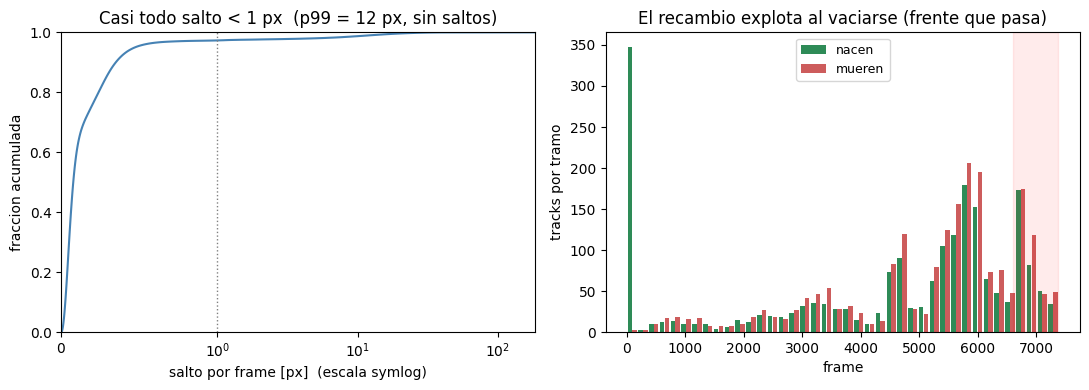

In [4]:
s = t.sort_values(['particle', 'frame'])
g = s.groupby('particle')

jump  = np.hypot(g['x'].diff(), g['y'].diff()).dropna()          # salto de una misma bolita [px/frame]
frag  = (g['frame'].diff() > 1).groupby(s['particle']).any().mean()   # % tracks con >=1 hueco
birth = g['frame'].min(); death = g['frame'].max()               # frame de nacimiento / muerte de cada track

print('SALTOS de una misma bolita (px/frame):')
print(f'  mediana {np.median(jump):.2f} | p95 {np.percentile(jump,95):.1f} | p99 {np.percentile(jump,99):.1f} | saltos >100px: {(jump>100).sum()} de {len(jump)} ({(jump>100).mean()*100:.3f}%)')
print(f'  => sin teletransportes: el linkeo es sano')
print(f'FRAGMENTACION: {frag*100:.0f}% de los tracks tienen al menos un hueco  => reapariciones = ids nuevas = falsa "duplicacion"')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].ecdf(jump.values, color='steelblue')
ax[0].axvline(1, color='gray', ls=':', lw=1)
ax[0].set_xscale('symlog', linthresh=1); ax[0].set_xlim(0, jump.max())
ax[0].set_xlabel('salto por frame [px]  (escala symlog)'); ax[0].set_ylabel('fraccion acumulada')
ax[0].set_title(f'Casi todo salto < 1 px  (p99 = {np.percentile(jump,99):.0f} px, sin saltos)')

nb = 40; edges = np.linspace(0, fmax, nb + 1); w = edges[1] - edges[0]; ctr = 0.5*(edges[:-1] + edges[1:])
bh, _ = np.histogram(birth, edges); dh, _ = np.histogram(death, edges)
ax[1].bar(ctr - w*0.22, bh, width=w*0.42, color='seagreen', label='nacen')
ax[1].bar(ctr + w*0.22, dh, width=w*0.42, color='indianred', label='mueren')
ax[1].axvspan(f_low, fmax, color='red', alpha=.08)
ax[1].set_xlabel('frame'); ax[1].set_ylabel('tracks por tramo'); ax[1].legend(fontsize=9)
ax[1].set_title('El recambio explota al vaciarse (frente que pasa)')
plt.tight_layout(); plt.show()

### 0.4 Las ráfagas de movimiento del final: ¿reales o artefacto?

Cerca del final aparece una **ráfaga**: de golpe muchas bolitas se mueven a la vez (pico naranja de
0.2). Como el silo ya está casi vacío, uno sospecha que podría ser ruido. Lo ponemos a prueba: una
ráfaga **real** de descarga tiene que verse como caída por gravedad, es decir

1. **coherente hacia abajo** — casi todas con `vy > 0` (en la imagen, y crece hacia abajo),
2. **de tracks continuos** — el movimiento sale de trayectorias sin huecos (`gap == 1`), no de
   reapariciones sueltas,
3. **persistente** — cada bolita se mueve durante muchos frames seguidos, no un parpadeo de 1 frame.

Comparamos la ráfaga contra la descarga **estable** del medio del video. Si se comportan igual, la
ráfaga es una **avalancha real de vaciado**, no un artefacto — sólo que con menos bolitas.

ventana                                %hacia_abajo  %continuo   med|vy|  persist(frames)
descarga estable (medio)                        98%        96%     384              21
RAFAGA final (frame 5975, t=75s)                99%        94%     657              14

=> la rafaga es hacia abajo, de tracks continuos y persistente, IGUAL que la descarga estable:
   es una AVALANCHA REAL de vaciado, no un artefacto (solo que con menos material).


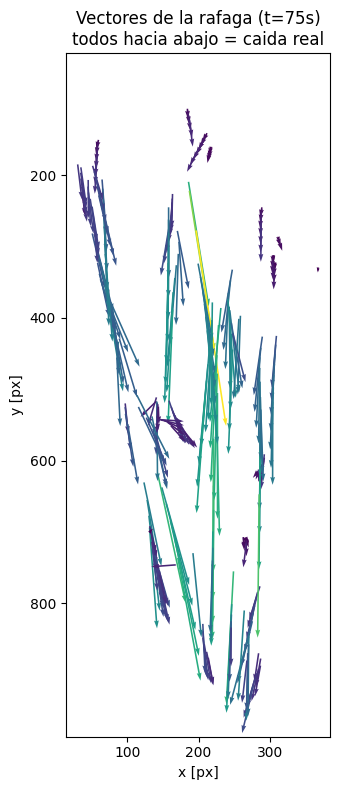

In [5]:
s['gap'] = g['frame'].diff()
s['mv']  = s['v'] * k > V_MOV
f_burst  = int(mpf.idxmax())                      # frame con mas bolitas moviles = la rafaga mas grande

def caracterizar(a, b, nombre):
    d  = s[(s.frame >= a) & (s.frame <= b)]
    mv = d[d.mv]
    # persistencia: frames consecutivos que cada bolita se mueve dentro de la ventana
    persist = mv.groupby('particle').size()
    return dict(nombre=nombre, n=len(mv),
                abajo=(mv.vy > 0).mean()*100,
                continuo=(mv.gap == 1).mean()*100,
                vy=mv.vy.abs().median()*k,
                persist=persist.median())

R = [caracterizar(2000, 2400, 'descarga estable (medio)'),
     caracterizar(f_burst-15, f_burst+15, f'RAFAGA final (frame {f_burst}, t={f_burst/FPS:.0f}s)')]
print(f'{"ventana":<38}{"%hacia_abajo":>13}{"%continuo":>11}{"med|vy|":>10}{"persist(frames)":>17}')
for r in R:
    print(f'{r["nombre"]:<38}{r["abajo"]:12.0f}%{r["continuo"]:10.0f}%{r["vy"]:8.0f}  {r["persist"]:14.0f}')
print('\n=> la rafaga es hacia abajo, de tracks continuos y persistente, IGUAL que la descarga estable:')
print('   es una AVALANCHA REAL de vaciado, no un artefacto (solo que con menos material).')

# imagen: mapa de vectores de la rafaga (una ventana corta) para verlo
d = s[(s.frame >= f_burst-3) & (s.frame <= f_burst+3) & s.mv]
fig, ax = plt.subplots(figsize=(4.5, 8))
ax.quiver(d.x, d.y, d.vx, d.vy, np.hypot(d.vx, d.vy)*k, cmap='viridis', angles='xy', scale=60, width=.006)
ax.set_ylim(t.y.max()+10, t.y.min()-10); ax.set_aspect('equal')
ax.set_xlabel('x [px]'); ax.set_ylabel('y [px]'); ax.set_title(f'Vectores de la rafaga (t={f_burst/FPS:.0f}s)\ntodos hacia abajo = caida real')
plt.tight_layout(); plt.show()

### 0.5 Lo que 0.2–0.4 NO muestran: ¿se conserva la cantidad de bolitas?

0.2 y 0.3 grafican **cuentas crudas** (bolitas/frame, nacimientos/muertes por tramo). El problema es
que una cuenta cruda puede "verse bien" y aun así esconder un problema: si nacen y mueren
aproximadamente la misma cantidad de tracks a la vez, el total no se mueve raro (0.2); y en la zona
de baja confianza las barras de 0.3 son chicas simplemente porque **queda poca gente**, no porque el
comportamiento sea sano — una TASA alta sobre poca población todavía da una barra chica.

El chequeo de **conservación**: una bolita real **entra por arriba** (`y` chico) y **sale por abajo**
(`y` grande) — no debería aparecer/desaparecer **en el medio**. Medimos la tasa de esos eventos por
bolita presente (no la cuenta cruda), excluyendo el frame 0 (ahí "nace" toda la población inicial,
que está en el medio del canal porque ahí está apilado el material — no es un evento real).

tasa de fragmentacion/bolita: base (fr 2000-4500) = 0.0005 | supera 3x desde frame 4450 (t=56s)
para comparar: N<50 arranca en frame 6602 (t=83s)  -> son dos señales DISTINTAS, no siempre coinciden


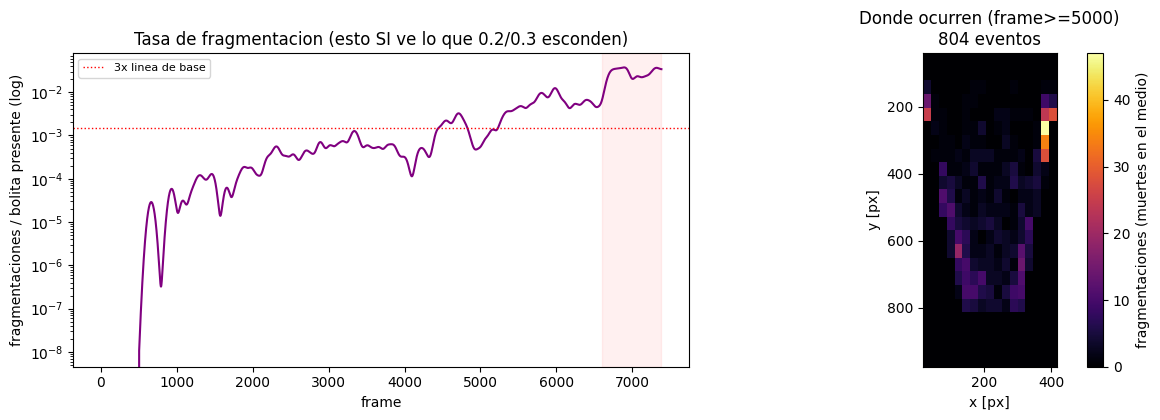


pico espacial: x~370-393, y~243-284  (47 eventos) -> define in_hotspot()


In [6]:
Y_TOP, Y_BOT = 150, 800                     # banda "interior": ni entrada (arriba) ni salida (abajo)

xf = g.first(); xl = g.last()                                    # primera/ultima deteccion de cada track (de 0.3)
ib  = xf[(xf.y > Y_TOP) & (xf.y < Y_BOT) & (xf.frame > 0)]        # nace en el medio (frame>0: excluye poblacion inicial)
idd = xl[(xl.y > Y_TOP) & (xl.y < Y_BOT) & (xl.frame < fmax)]     # muere en el medio
ppf_full = ppf.reindex(range(fmax + 1), fill_value=0)
ibpf = ib.frame.value_counts().reindex(range(fmax + 1), fill_value=0).sort_index()
idpf = idd.frame.value_counts().reindex(range(fmax + 1), fill_value=0).sort_index()
events = (ibpf + idpf).astype(float)
rate = np.divide(events.values, ppf_full.values, out=np.zeros(len(events)), where=ppf_full.values > 0)
rate_s = gaussian_filter1d(rate, 40)                              # tasa de fragmentacion / bolita presente

base = np.median(rate_s[2000:4500])                               # linea de base en la descarga estable
thr = 3 * base
bad = np.where((rate_s > thr) & (np.arange(fmax + 1) > 1000))[0]
f_frag = int(bad.min()) if len(bad) else fmax
frag_ok = pd.Series(rate_s <= thr, index=range(fmax + 1)); frag_ok.iloc[:1000] = True   # <- flag reutilizable

def in_hotspot(x, y):                                              # <- mascara espacial reutilizable
    """Región derecha con exceso de fragmentación, ver más abajo."""
    return (x > 360) & (x < 410) & (y > 150) & (y < 400)

print(f'tasa de fragmentacion/bolita: base (fr 2000-4500) = {base:.4f} | supera 3x desde frame {f_frag} (t={f_frag/FPS:.0f}s)')
print(f'para comparar: N<{N_MIN} arranca en frame {f_low} (t={f_low/FPS:.0f}s)  -> son dos señales DISTINTAS, no siempre coinciden')

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].plot(np.arange(fmax + 1), rate_s, color='purple')
ax[0].axhline(thr, color='red', ls=':', lw=1, label='3x linea de base')
ax[0].axvspan(f_low, fmax, color='red', alpha=.06)
ax[0].set_yscale('log'); ax[0].set_xlabel('frame'); ax[0].set_ylabel('fragmentaciones / bolita presente (log)')
ax[0].set_title('Tasa de fragmentacion (esto SI ve lo que 0.2/0.3 esconden)'); ax[0].legend(fontsize=8)

late = idd[idd.frame >= 5000]
H, xe, ye = np.histogram2d(late.x, late.y, bins=[np.linspace(t.x.min(), t.x.max(), 18),
                                                  np.linspace(t.y.min(), t.y.max(), 24)])
im = ax[1].imshow(H.T, origin='upper', extent=[xe[0], xe[-1], ye[-1], ye[0]], aspect='equal', cmap='inferno')
fig.colorbar(im, ax=ax[1], label='fragmentaciones (muertes en el medio)')
ax[1].set_xlabel('x [px]'); ax[1].set_ylabel('y [px]')
ax[1].set_title(f'Donde ocurren (frame>=5000)\n{len(late)} eventos')
plt.tight_layout(); plt.show()

hot_j, hot_i = np.unravel_index(H.argmax(), H.shape)
print(f'\npico espacial: x~{xe[hot_j]:.0f}-{xe[hot_j+1]:.0f}, y~{ye[hot_i]:.0f}-{ye[hot_i+1]:.0f}  ({H.max():.0f} eventos) -> define in_hotspot()')

### 0.6 ¿Son bolitas falsas, o bolitas reales cortadas en dos?

Cuidado: que un track "nazca o muera en el medio" **no prueba que sea falso**. Una bolita real que
cae y el tracker pierde un rato (mucho movimiento, tapada por otra) también "nace y muere en el
medio" — es la misma bolita, solo que cortada en dos tracks. Eso ya lo sabíamos (0.3): ~56% de los
tracks tienen algún hueco. Antes de acusar al video hay que descartar esa explicación más simple.

Comparamos la zona sospechosa (`in_hotspot`, definida arriba) contra el resto del canal, en frames
≥5000, con dos chequeos que **si** distinguen "bolita real cortada" de "mancha falsa":
- **Velocidad al nacer/morir**: una mancha falsa (parpadeo de iluminación) sería ~quieta; una bolita
  real cortada a mitad de caída tiene velocidad real.
- **Duración del track**: una mancha falsa duraría 1-2 frames; una bolita real cortada dura muchos
  frames (es una porción real de trayectoria).
- **Saltos de una misma bolita** (de 0.3): si el defecto del video afecta la detección justo ahí, se
  esperarían más saltos grandes de una MISMA id en esa zona que en el resto.

In [7]:
hot_of  = lambda df: df[in_hotspot(df.x, df.y) & (df.frame >= 5000)]
rest_of = lambda df: df[~in_hotspot(df.x, df.y) & (df.frame >= 5000)]
hb, hd = hot_of(ib), hot_of(idd)
rb, rd = rest_of(ib), rest_of(idd)
span = g['frame'].agg(lambda a: a.max() - a.min() + 1)                    # duracion de cada track

step_jump = np.hypot(g['x'].diff(), g['y'].diff())
tj = t.assign(jump=step_jump)                                             # align por indice (no por posicion)
hj = tj.loc[in_hotspot(tj.x, tj.y) & (tj.frame >= 5000), 'jump'].dropna()
rj = tj.loc[~in_hotspot(tj.x, tj.y) & (tj.frame >= 5000), 'jump'].dropna()

print(f'{"":<28}{"HOTSPOT":>12}{"RESTO":>12}')
print(f'{"vel. al morir [mm/s]":<28}{hd.v.median()*k:12.0f}{rd.v.median()*k:12.0f}   (>0 en los dos => movimiento real, no mancha quieta)')
print(f'{"vel. al nacer [mm/s]":<28}{hb.v.median()*k:12.0f}{rb.v.median()*k:12.0f}')
print(f'{"duracion mediana [frames]":<28}{span.loc[hb.index].median():12.0f}{span.loc[rb.index].median():12.0f}   (similar y >>1 => no son parpadeos)')
print(f'{"saltos misma-bolita >40px":<28}{(hj>40).mean()*100:11.2f}%{(rj>40).mean()*100:11.2f}%   (mas alto en hotspot => localizado ahi)')

print('''
CONCLUSION (corregida): la velocidad y duracion muestran que esto NO son manchas falsas quietas —
son BOLITAS REALES cuyo track se corta a mitad de camino (fragmentacion comun, ya vista en 0.3).
Lo que SI es real y localizado: la fragmentacion ahi es mas frecuente de lo que explicaria el
movimiento local (frame_ok/frag_ok abajo), y los saltos de una misma id tambien son mas altos ahi.
Es una senal MODESTA pero repetida en 2 chequeos independientes -> queda como hipotesis abierta de
un problema puntual de deteccion en esa zona (ej. iluminacion), NO como bolitas fantasma probadas.
''')

                                 HOTSPOT       RESTO
vel. al morir [mm/s]                 480        1178   (>0 en los dos => movimiento real, no mancha quieta)
vel. al nacer [mm/s]                 367         432
duracion mediana [frames]             29          25   (similar y >>1 => no son parpadeos)
saltos misma-bolita >40px          0.22%       0.13%   (mas alto en hotspot => localizado ahi)

CONCLUSION (corregida): la velocidad y duracion muestran que esto NO son manchas falsas quietas —
son BOLITAS REALES cuyo track se corta a mitad de camino (fragmentacion comun, ya vista en 0.3).
Lo que SI es real y localizado: la fragmentacion ahi es mas frecuente de lo que explicaria el
movimiento local (frame_ok/frag_ok abajo), y los saltos de una misma id tambien son mas altos ahi.
Es una senal MODESTA pero repetida en 2 chequeos independientes -> queda como hipotesis abierta de
un problema puntual de deteccion en esa zona (ej. iluminacion), NO como bolitas fantasma probadas.



### 0.7 Resumen: dos señales de confianza, no una

En vez de un solo corte tipo "descartamos todo después de tal frame", dejamos **dos banderas
independientes** disponibles para el resto del notebook — porque miden cosas distintas y no siempre
coinciden (una puede fallar sin que falle la otra):

- **`frame_ok[frame]`** — ¿hay suficientes bolitas (`N ≥ N_MIN=50`) para promediar espacialmente? Es
  sobre **cantidad**. Se rompe en el frame 6602 (t≈83s).
- **`frag_ok[frame]`** — ¿la tasa de fragmentación está cerca de lo normal, o se disparó (>3x la
  base)? Es sobre **calidad**, y se degrada ANTES que `frame_ok`: frame 4450 (t≈56s).
- **`in_hotspot(x, y)`** — la región espacial puntual (x 360–410, y 150–400) con el exceso de
  fragmentación de 0.6. Es sobre **dónde**, no sobre cuándo.

Nada se borra: estas tres funciones quedan para que las secciones siguientes (en particular el mapa
de zonas, sección 4) puedan mostrar el resultado con y sin la zona/tiempo marcados, en vez de
imponer un único corte arbitrario.

## 1. Filtrado de vectores malos

Algunas lecturas de velocidad son físicamente imposibles (una bolita "acelerando" a miles de mm/s en
un frame). La cola de la distribución no tiene un quiebre natural donde cortar — el corte sale de una
regla estadística estándar: la **cerca de Tukey** (`Q3 + 3×IQR` sobre las bolitas móviles), el mismo
criterio que arma los bigotes de un boxplot.

In [8]:
s = t.sort_values(['particle', 'frame']).copy()
s['gap'] = s.groupby('particle')['frame'].diff()          # se usa en sec. 3 (onset)

# umbral estatico/movil preliminar (datos crudos), solo para aislar "movil" y calcular el IQR
v0 = s['v'].values; v0 = v0[v0 > 0]; logv0 = np.log10(v0)
h0, e0 = np.histogram(logv0, 120); c0 = 0.5 * (e0[:-1] + e0[1:])
hs0 = gaussian_filter1d(h0.astype(float), 3)
idx0, kinds0 = local_extrema(hs0)
v_static_prelim = 10 ** c0[idx0[kinds0.index('min')]] * k

vmm = s['v'].values * k
mob_mm = vmm[vmm > v_static_prelim]
q1, q3 = np.percentile(mob_mm, [25, 75]); iqr = q3 - q1
V_CUT = round((q3 + 3 * iqr) / 10) * 10                    # cerca de Tukey extrema

keep = vmm <= V_CUT
tc = s[keep].copy()

print(f'V_CUT = Q3 + 3*IQR = {V_CUT:.0f} mm/s  (Q1={q1:.0f}, Q3={q3:.0f}, IQR={iqr:.0f})')
print(f'muestras: {len(s)} -> {len(tc)}  ({100*(1-len(tc)/len(s)):.3f}% descartado)')
print(f'maximo: {vmm.max():.0f} -> {vmm[keep].max():.0f} mm/s')

V_CUT = Q3 + 3*IQR = 2650 mm/s  (Q1=301, Q3=888, IQR=588)
muestras: 1765517 -> 1765421  (0.005% descartado)
maximo: 6892 -> 2647 mm/s


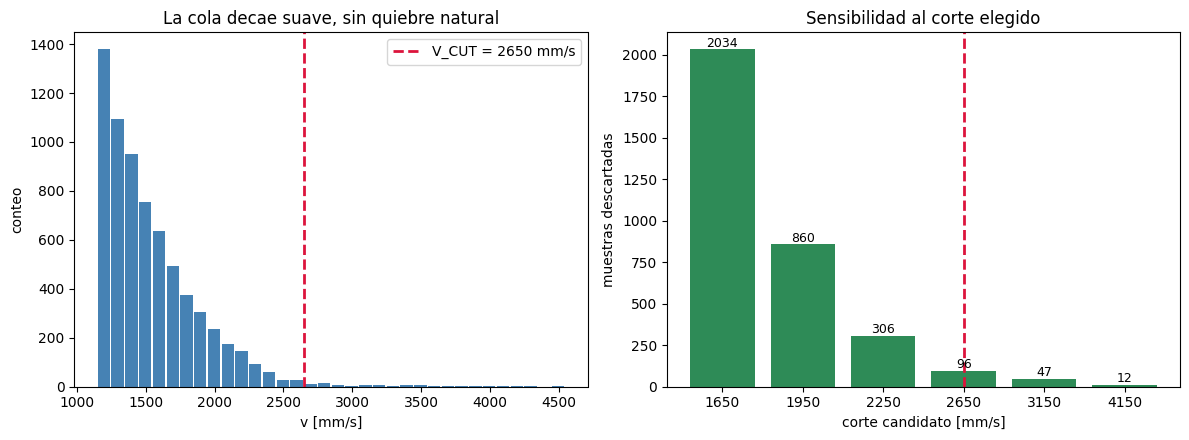

In [9]:
cuts_candidatos = sorted(set([V_CUT - 1000, V_CUT - 700, V_CUT - 400, V_CUT, V_CUT + 500, V_CUT + 1500]))
cuts_candidatos = [c for c in cuts_candidatos if c > 0]
dropped_candidatos = [np.sum(vmm > c) for c in cuts_candidatos]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

edges = np.arange(max(0, V_CUT - 1500), V_CUT + 2000, 100)
hist, _ = np.histogram(vmm, edges)
ax[0].bar(edges[:-1], hist, width=90, color='steelblue', align='edge')
ax[0].axvline(V_CUT, color='crimson', ls='--', lw=2, label=f'V_CUT = {V_CUT:.0f} mm/s')
ax[0].set_xlabel('v [mm/s]'); ax[0].set_ylabel('conteo')
ax[0].set_title('La cola decae suave, sin quiebre natural')
ax[0].legend()

ax[1].bar([str(c) for c in cuts_candidatos], dropped_candidatos, color='seagreen')
for i, d in enumerate(dropped_candidatos):
    ax[1].text(i, d + 15, str(d), ha='center', fontsize=9)
ax[1].axvline(cuts_candidatos.index(V_CUT), color='crimson', ls='--', lw=2)
ax[1].set_xlabel('corte candidato [mm/s]'); ax[1].set_ylabel('muestras descartadas')
ax[1].set_title('Sensibilidad al corte elegido')
plt.tight_layout(); plt.show()

### 1.1 Chequeo independiente: techo físico

Comparamos `V_CUT` contra la velocidad de **caída libre sin fricción** sobre la altura de caída
visible en el video (`v = sqrt(2·g·h)`). Ningún grano puede superar ese número físicamente.

In [10]:
G_MMS2 = 9810                                        # gravedad, mm/s^2
h_mm = (t['y'].max() - t['y'].min()) / PXMM
v_ceiling = np.sqrt(2 * G_MMS2 * h_mm)

print(f'altura de caida visible: {h_mm:.0f} mm')
print(f'techo de caida libre (sin roce): {v_ceiling:.0f} mm/s')
print(f'V_CUT: {V_CUT:.0f} mm/s -> {"por debajo del techo, consistente" if V_CUT < v_ceiling else "OJO: por encima del techo"}')
print(f'maximo crudo: {vmm.max():.0f} mm/s -> {"supera el techo fisico: imposible que sea real" if vmm.max() > v_ceiling else "por debajo del techo"}')

altura de caida visible: 670 mm
techo de caida libre (sin roce): 3625 mm/s
V_CUT: 2650 mm/s -> por debajo del techo, consistente
maximo crudo: 6892 mm/s -> supera el techo fisico: imposible que sea real


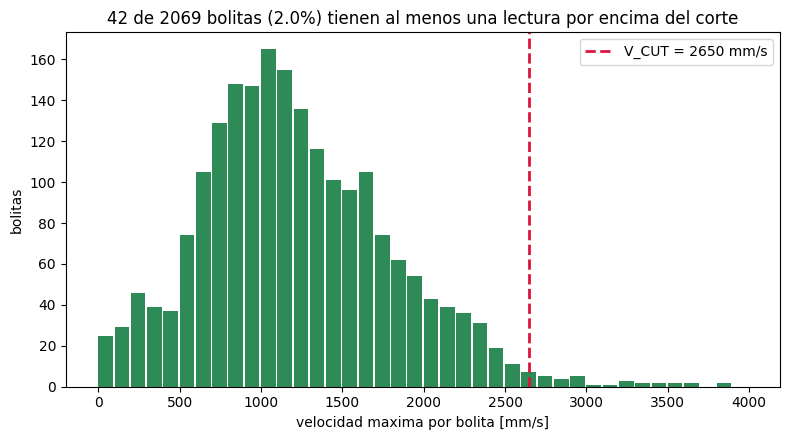

In [11]:
maxv = s.assign(vmm=vmm).groupby('particle')['vmm'].max()
n_bad = (maxv > V_CUT).sum()

fig, ax = plt.subplots(figsize=(8, 4.5))
edges = np.arange(0, 4100, 100)
hist, _ = np.histogram(maxv, edges)
ax.bar(edges[:-1], hist, width=90, color='seagreen', align='edge')
ax.axvline(V_CUT, color='crimson', ls='--', lw=2, label=f'V_CUT = {V_CUT:.0f} mm/s')
ax.set_xlabel('velocidad maxima por bolita [mm/s]')
ax.set_ylabel('bolitas')
ax.set_title(f'{n_bad} de {len(maxv)} bolitas ({n_bad/len(maxv)*100:.1f}%) tienen al menos '
             f'una lectura por encima del corte')
ax.legend(); plt.tight_layout(); plt.show()

### 1.2 Campo de velocidad, antes y después

`render_velocity_field(...)` anima el campo (vx/vy promediado por celda) sin depender de variables
globales. Se llama sobre `t` (crudo) y `tc` (limpio) con el mismo `vmax`, para comparar a ojo.

In [12]:
def render_velocity_field(df, xb, yb, frames=None, step=4, k=1.0, cmap='plasma', scale=8000,
                          vmax=None, invert_y=True, label='', out=None, outdir='.',
                          capture_fps=None, fps=20, dpi=80):
    """Anima el campo de velocidad (grilla, vx/vy promedio por celda), frame a frame. REUTILIZABLE.

    df           : tabla con columnas 'x','y','frame','vx','vy'.
    xb, yb       : bordes de la grilla. Pasar los MISMOS bins a dos llamadas para que sean comparables.
    k            : factor de calibracion px/frame -> unidades fisicas (1.0 = sin convertir).
    scale        : escala de quiver (mas chico = flechas mas largas); ajustar segun las unidades de k.
    vmax         : techo de la escala de color (None = auto, p99 de las celdas ocupadas). Para
                   comparar dos campos entre si, pasar un vmax compartido a las dos llamadas.
    out/outdir   : ruta del mp4 (default outdir/field.mp4).
    capture_fps  : fps del video original, solo para el t=frame/capture_fps del titulo (opcional).
    """
    nx, ny = len(xb) - 1, len(yb) - 1
    d = df[['x', 'y', 'frame', 'vx', 'vy']].copy()
    d['xi'] = np.clip(np.digitize(d['x'], xb) - 1, 0, nx - 1)
    d['yi'] = np.clip(np.digitize(d['y'], yb) - 1, 0, ny - 1)
    grid = d.groupby(['frame', 'yi', 'xi'])[['vx', 'vy']].mean()

    def dense(fr, col):
        try:
            g2 = grid.loc[fr][col].unstack(fill_value=0)
            return g2.reindex(index=range(ny), columns=range(nx), fill_value=0).values
        except KeyError:
            return np.zeros((ny, nx))

    if frames is None:
        frames = range(0, int(df['frame'].max()) + 1, step)
    frames = list(frames)

    if vmax is None:
        speed = np.hypot(grid['vx'], grid['vy']).values * k   # percentil sobre celdas ocupadas, no la grilla sparse
        vmax = np.percentile(speed, 99) if len(speed) else 1.0

    X, Y = np.meshgrid(np.arange(nx), np.arange(ny))
    fig, ax = plt.subplots(figsize=(6, 9))
    vx0, vy0 = dense(frames[0], 'vx')*k, dense(frames[0], 'vy')*k
    Q = ax.quiver(X, Y, vx0, vy0, np.hypot(vx0, vy0), angles='xy', cmap=cmap, scale=scale,
                  width=.006, clim=(0, vmax))
    if invert_y: ax.invert_yaxis()
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(Q, ax=ax, label='velocidad promedio por celda', shrink=.7)
    ttl = ax.set_title(label)

    def upd(i):
        fr = frames[i]
        tstr = f' | t={fr/capture_fps:.1f}s' if capture_fps else f' | frame {fr}'
        vx, vy = dense(fr, 'vx')*k, dense(fr, 'vy')*k
        Q.set_UVC(vx, vy, np.hypot(vx, vy))
        ttl.set_text(f'{label}{tstr}')
        return Q, ttl

    out = out or f'{outdir}/field.mp4'
    FuncAnimation(fig, upd, frames=len(frames), interval=1000/fps, blit=False).save(
        out, writer='ffmpeg', fps=fps, dpi=dpi)
    plt.close(fig)
    return Video(out, embed=True)

_d = np.load('../outputs/velocity_field.npz')
xb, yb = _d['x_bins'], _d['y_bins']

# vmax compartido para que ambas animaciones sean comparables
_speed_raw = np.hypot(t['vx'], t['vy']).values * k
_speed_tc  = np.hypot(tc['vx'], tc['vy']).values * k
vmax_field = np.percentile(np.concatenate([_speed_raw, _speed_tc]), 99)

render_velocity_field(t, xb, yb, step=4, k=k, capture_fps=FPS, vmax=vmax_field,
                      label='CRUDO (t)', out=f'{OUTDIR}/field_raw.mp4')

In [13]:
render_velocity_field(tc, xb, yb, step=4, k=k, capture_fps=FPS, vmax=vmax_field,
                      label='LIMPIO (tc)', out=f'{OUTDIR}/field_clean.mp4')

## 2. Estático vs móvil + distribución de velocidad → rango de transición

Buscamos los **máximos y mínimos locales** de la densidad de velocidades, sin ventanas de búsqueda
fijas. Se hace en dos pasos porque estático y móvil viven en escalas muy distintas (estático ~1
mm/s, móvil hasta miles):

- **Borde inferior** (estático\|móvil): sobre `log10(v)` de todos los datos limpios.
- **Borde superior** (dentro de lo móvil, lento\|rápido): sobre `v` lineal, sólo bolitas móviles.

In [14]:
v = tc['v'].values; v = v[v > 0]; logv = np.log10(v)
nb_bins = int(np.sqrt(len(logv)))                    # regla sqrt(n), misma que 2.1 -- no un numero fijo
hist, edges = np.histogram(logv, nb_bins); centers = 0.5*(edges[:-1]+edges[1:])
hs = gaussian_filter1d(hist.astype(float), 3 * nb_bins / 120)   # sigma escala con la resolucion
idx, kinds = local_extrema(hs)
print(f'estructura ({nb_bins} bins):', [f'{kd}={10**centers[i]*k:.0f}mm/s' for i, kd in zip(idx, kinds)])

v_static = 10 ** centers[idx[kinds.index('min')]]
print(f'umbral estatico/movil = {v_static*k:.0f} mm/s')

mob = tc[tc['v'] > v_static].copy()
print(f'moviles: {len(mob)}')

estructura (1328 bins): ['max=1mm/s', 'min=52mm/s', 'max=654mm/s']
umbral estatico/movil = 52 mm/s
moviles: 48118


### Borde superior — dentro de lo móvil

Misma idea, sobre `v` lineal y sólo con `mob` (bolitas ya móviles). El rango encontrado no tiene un
pico propio — es la cola descendente de la población recién móvil, hasta que la caída (pico ~500
mm/s) domina; el valle que lo separa de la caída sigue siendo real.

rango de transicion = 52-260 mm/s  |  pico de caida ~498 mm/s


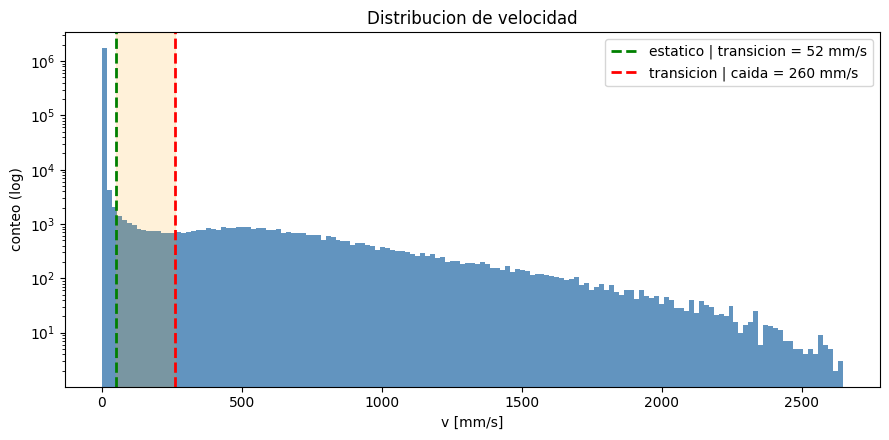

In [15]:
mms = mob['v'].values * k
nb_bins_mob = int(np.sqrt(len(mms)))                  # regla sqrt(n)
hh, ee = np.histogram(mms, np.linspace(mms.min(), mms.max(), nb_bins_mob)); cc = 0.5*(ee[:-1]+ee[1:])
hh2 = gaussian_filter1d(hh.astype(float), 2 * nb_bins_mob / 120)
idx2, kinds2 = local_extrema(hh2)

v_valley = cc[idx2[kinds2.index('min')]]
p_fall = cc[idx2[kinds2.index('max')]]
lo, hi = v_static*k, v_valley
print(f'rango de transicion = {lo:.0f}-{hi:.0f} mm/s  |  pico de caida ~{p_fall:.0f} mm/s')

fig, ax = plt.subplots(figsize=(9, 4.5))
vfull = tc['v'].values * k
ax.hist(vfull, bins=np.linspace(0, vfull.max(), 150), color='steelblue', alpha=.85)
ax.axvline(lo, color='green', ls='--', lw=2, label=f'estatico | transicion = {lo:.0f} mm/s')
ax.axvline(hi, color='red',   ls='--', lw=2, label=f'transicion | caida = {hi:.0f} mm/s')
ax.axvspan(lo, hi, color='orange', alpha=.15)
ax.set_yscale('log'); ax.set_xlabel('v [mm/s]'); ax.set_ylabel('conteo (log)')
ax.set_title('Distribucion de velocidad')
ax.legend()
plt.tight_layout(); plt.show()

### Tag por muestra — estático / transición / caída

Con los dos umbrales ya derivados, etiquetamos cada lectura `(particula, frame)` de una vez — se
reutiliza en el resto del notebook en vez de recalcularse cada vez que hace falta.

In [16]:
v_hi_pxf = hi / k                      # borde superior de transicion, en px/f (mismas unidades que v_static)
t['reg'] = np.where(t['v'] < v_static, 'static',
             np.where(t['v'] < v_hi_pxf, 'trans', 'fall'))
t['reg_code'] = pd.Categorical(t['reg'], categories=['static', 'trans', 'fall']).codes
t['reg'].value_counts()

reg
static    1717303
fall        37796
trans       10418
Name: count, dtype: int64

### 2.1 Piso de ruido — ¿el umbral inferior es real?

Bolitas verdaderamente quietas tienen una velocidad medida que no es cero — es jitter de
localización del tracker. Si `v_static` está por encima de ese piso de ruido, es un umbral sano.

Para aislar momentos quietos usamos el radio de la trayectoria — pero calculado en una **ventana
corta alrededor de cada muestra** (no sobre el track completo): una muestra cuenta como "quieta" si
la bolita casi no se movió en los ±15 frames alrededor de ese instante. Así, si esa misma bolita se
mueve mucho antes o después (por ejemplo, la muestra es del final de una caída real que recién está
frenando), esa contaminación no se filtra a las muestras vecinas que sí están quietas.

radio local: valle en 17.6 px -> 1698350 de 1715449 muestras "localmente quietas"
piso de ruido: mediana=0.8 p99=7.1 max=343.1 mm/s
umbral estatico/movil = 52 mm/s -> umbral sano


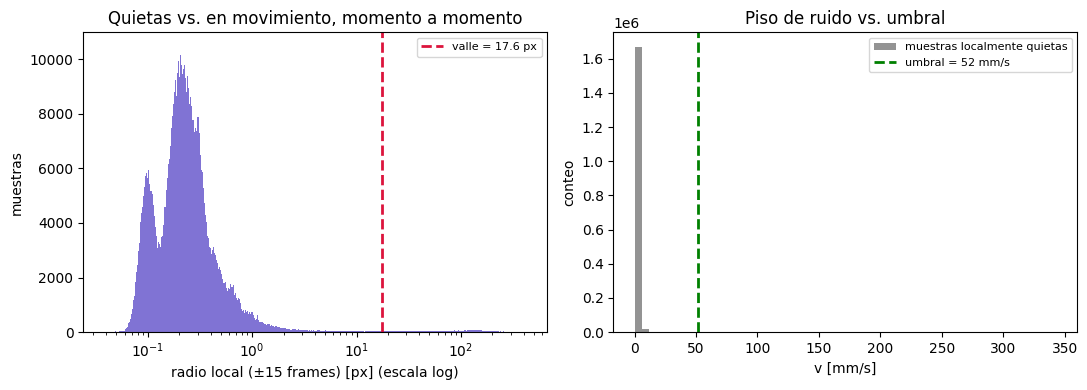

In [17]:
W = 15                                                      # medio-ancho de ventana [frames]
tcs = tc.sort_values(['particle', 'frame']).reset_index(drop=True)
g = tcs.groupby('particle')
xr = g['x'].rolling(2*W+1, center=True, min_periods=2*W+1).apply(lambda a: a.max()-a.min(), raw=True).reset_index(level=0, drop=True)
yr = g['y'].rolling(2*W+1, center=True, min_periods=2*W+1).apply(lambda a: a.max()-a.min(), raw=True).reset_index(level=0, drop=True)
tcs['local_rad'] = 0.5 * np.hypot(xr.values, yr.values)     # radio de la trayectoria EN ESA VENTANA [px]
valid = tcs.dropna(subset=['local_rad'])

logr = np.log10(valid['local_rad'].values[valid['local_rad'].values > 0])
nb_bins = int(np.sqrt(len(logr)))
hist, edges = np.histogram(logr, nb_bins); centers = 0.5 * (edges[:-1] + edges[1:])
hs = gaussian_filter1d(hist.astype(float), 3 * nb_bins / 120)
idx_r, kinds_r = local_extrema(hs)
r_valley = 10 ** centers[idx_r[kinds_r.index('min')]]

quiet = valid['local_rad'] < r_valley
noise = valid.loc[quiet, 'v'].values * k

print(f'radio local: valle en {r_valley:.1f} px -> {quiet.sum()} de {len(valid)} muestras "localmente quietas"')
print(f'piso de ruido: mediana={np.median(noise):.1f} p99={np.percentile(noise,99):.1f} max={noise.max():.1f} mm/s')
veredicto = 'umbral sano' if v_static*k > np.percentile(noise, 99) else 'OJO: cerca del ruido'
print(f'umbral estatico/movil = {v_static*k:.0f} mm/s -> {veredicto}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
rad_vals = valid['local_rad'].values
ax[0].hist(rad_vals[rad_vals > 0], bins=10**edges, color='slateblue', alpha=.85)
ax[0].set_xscale('log')
ax[0].axvline(r_valley, color='crimson', ls='--', lw=2, label=f'valle = {r_valley:.1f} px')
ax[0].set_xlabel('radio local (±15 frames) [px] (escala log)'); ax[0].set_ylabel('muestras')
ax[0].set_title('Quietas vs. en movimiento, momento a momento'); ax[0].legend(fontsize=8)

ax[1].hist(noise, bins=np.linspace(0, max(150, noise.max()), 60), color='gray', alpha=.85,
           label='muestras localmente quietas')
ax[1].axvline(v_static*k, color='green', ls='--', lw=2, label=f'umbral = {v_static*k:.0f} mm/s')
ax[1].set_xlabel('v [mm/s]'); ax[1].set_ylabel('conteo')
ax[1].set_title('Piso de ruido vs. umbral'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### 2.2 ¿Importa la cantidad de bins?

La resolución del histograma sale de una regla estándar (`√n`, misma que arriba), no de un número
fijo. Igual lo probamos con varias resoluciones distintas para confirmar que no importa.

valle entre resoluciones: 251-260 mm/s (4% de variacion sobre 260)


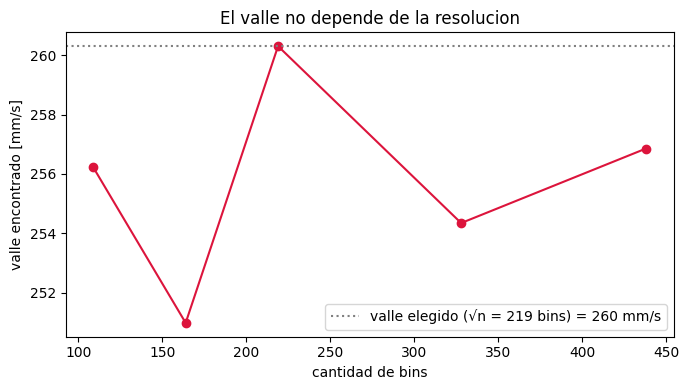

In [18]:
bin_counts = sorted(set([nb_bins_mob // 2, int(nb_bins_mob*0.75), nb_bins_mob, int(nb_bins_mob*1.5), nb_bins_mob*2]))
rows = []
for nb in bin_counts:
    hh_b, ee_b = np.histogram(mms, np.linspace(mms.min(), mms.max(), nb))
    cc_b = 0.5 * (ee_b[:-1] + ee_b[1:])
    hh2_b = gaussian_filter1d(hh_b.astype(float), 2 * nb / 120)
    idx_b, kinds_b = local_extrema(hh2_b)
    v_valley_b = cc_b[idx_b[kinds_b.index('min')]] if 'min' in kinds_b else np.nan
    rows.append(v_valley_b)

print(f'valle entre resoluciones: {min(rows):.0f}-{max(rows):.0f} mm/s '
      f'({(max(rows)-min(rows))/v_valley*100:.0f}% de variacion sobre {v_valley:.0f})')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bin_counts, rows, 'o-', color='crimson')
ax.axhline(v_valley, color='gray', ls=':', label=f'valle elegido (√n = {nb_bins_mob} bins) = {v_valley:.0f} mm/s')
ax.set_xlabel('cantidad de bins'); ax.set_ylabel('valle encontrado [mm/s]')
ax.set_title('El valle no depende de la resolucion')
ax.legend(); plt.tight_layout(); plt.show()

## 3. Chequeo: la transición **es** "empezar a moverse"

Detectamos, por trayectoria, el **onset** (cuando una bolita cruza de estática a móvil). Su
velocidad en ese instante es baja (~borde inferior) y en los frames siguientes **acelera** cruzando
el rango de transición hacia la caída. Confirma que el rango encontrado es la fase de arranque.

In [19]:
s['mv'] = s['v'] > v_static
s['prev'] = s.groupby('particle')['mv'].shift(1)
s['onset'] = s['mv'] & (s['prev'] == False) & (s['gap'] == 1)
oi = s.index[s['onset']]
print(f'eventos de onset: {len(oi)} | velocidad en el onset = {np.nanmedian(s.loc[oi,"v"])*k:.0f} mm/s')
print('velocidad (mediana) despues del onset, misma bolita:')
for kk in [0, 1, 3, 5, 8, 12]:
    col = s['v'] if kk == 0 else s.groupby('particle')['v'].shift(-kk)
    print(f'  +{kk:2d} frames: {np.nanmedian(col.loc[oi])*k:4.0f} mm/s')

eventos de onset: 1291 | velocidad en el onset = 64 mm/s
velocidad (mediana) despues del onset, misma bolita:
  + 0 frames:   64 mm/s
  + 1 frames:   92 mm/s
  + 3 frames:  158 mm/s
  + 5 frames:  223 mm/s
  + 8 frames:  335 mm/s
  +12 frames:  491 mm/s


## 4. Mapa de zonas

Coarse-graining en grilla. Clasificamos cada celda por la **velocidad de caída típica (mediana) de
sus bolitas móviles**:
- **Estático**: hay bolitas pero casi no se mueven (móvil < 2% del tiempo).
- **Transición**: velocidad típica dentro del rango de transición.
- **Caída**: velocidad típica por encima del borde superior.

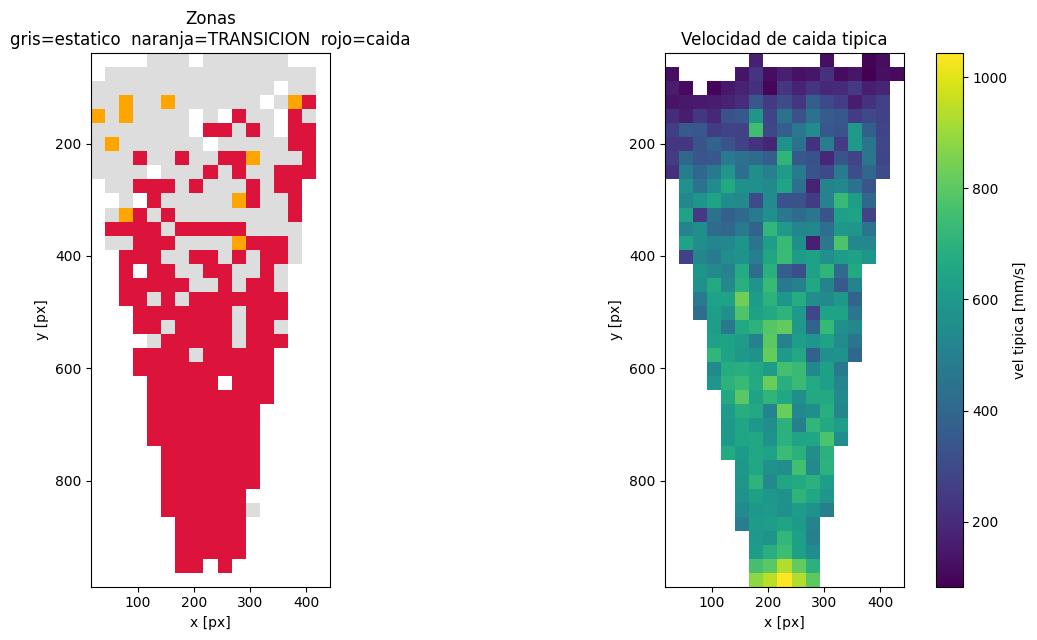

In [20]:
d = np.load('../outputs/velocity_field.npz'); xb, yb = d['x_bins'], d['y_bins']
nx, ny = len(xb)-1, len(yb)-1
dx, dy = np.diff(xb).mean(), np.diff(yb).mean(); cell_cm2 = (dx/PXMM/10)*(dy/PXMM/10)
ci = lambda col, bins: np.clip(np.digitize(col, bins)-1, 0, len(bins)-2)
t['xi'], t['yi'] = ci(t['x'], xb), ci(t['y'], yb)
mob['xi'], mob['yi'] = ci(mob['x'], xb), ci(mob['y'], yb)
G = lambda ser: ser.unstack(fill_value=0).reindex(index=range(ny), columns=range(nx), fill_value=0).values
ntot = G(t.groupby(['yi', 'xi']).size())
nmob = G(mob.groupby(['yi', 'xi']).size())
Vmed = np.full((ny, nx), np.nan)                       # vel de caida tipica por celda [mm/s]
for (j, i), val in mob.groupby(['yi', 'xi'])['v'].median().items(): Vmed[j, i] = val*k
mobfrac = np.divide(nmob, ntot, out=np.zeros((ny, nx)), where=ntot > 0)

present = ntot > 200
flow    = present & (mobfrac >= 0.02) & (nmob >= 10)
static      = present & (mobfrac < 0.02)
transition  = flow & (Vmed >= lo) & (Vmed < hi)
falling     = flow & (Vmed >= hi)

Z = np.full((ny, nx), np.nan); Z[static] = 0; Z[transition] = 1; Z[falling] = 2
ext = [xb[0], xb[-1], yb[-1], yb[0]]
fig, ax = plt.subplots(1, 2, figsize=(12, 6.5))
ax[0].imshow(Z, cmap=ListedColormap(['#dddddd', 'orange', 'crimson']), origin='upper',
             extent=ext, aspect='equal', interpolation='nearest')
ax[0].set_title('Zonas\ngris=estatico  naranja=TRANSICION  rojo=caida')
im = ax[1].imshow(Vmed, cmap='viridis', origin='upper', extent=ext, aspect='equal')
fig.colorbar(im, ax=ax[1], label='vel tipica [mm/s]'); ax[1].set_title('Velocidad de caida tipica')
for a in ax: a.set_xlabel('x [px]'); a.set_ylabel('y [px]')
plt.tight_layout(); plt.show()

## 5. Área de la zona de transición (descompresión)

In [21]:
A = lambda m: m.sum() * cell_cm2
print(f'celda = {cell_cm2:.2f} cm^2')
print('=== AREAS (cm^2) ===')
print(f'  estatico   : {A(static):6.1f}')
print(f'  TRANSICION : {A(transition):6.1f}   <-- ZONA DE DESCOMPRESION ({transition.sum()} celdas)')
print(f'  caida      : {A(falling):6.1f}')

print('\nsensibilidad al borde superior del rango de transicion:')
for hi_test in [hi - 50, hi, hi + 50, hi + 100]:                 # relativo al valle encontrado, no un numero suelto
    tr = flow & (Vmed >= lo) & (Vmed < hi_test)
    print(f'  transicion {lo:.0f}-{hi_test:3.0f} mm/s : {A(tr):6.1f} cm^2 ({tr.sum()} celdas)')

celda = 3.19 cm^2
=== AREAS (cm^2) ===
  estatico   :  513.4
  TRANSICION :   31.9   <-- ZONA DE DESCOMPRESION (10 celdas)
  caida      :  692.0

sensibilidad al borde superior del rango de transicion:
  transicion 52-210 mm/s :   15.9 cm^2 (5 celdas)
  transicion 52-260 mm/s :   31.9 cm^2 (10 celdas)
  transicion 52-310 mm/s :   54.2 cm^2 (17 celdas)
  transicion 52-360 mm/s :   82.9 cm^2 (26 celdas)


## 6. Animación: la banda de transición en el tiempo

**Toda la descarga** (~7000 frames, submuestreada 1 de cada 4). **Naranja = bolitas en el rango de
transición**, gris = estático, rojo = caída. Se ve el **frente de descompresión**: las naranjas
aparecen en el borde superior del material móvil — donde el bloque estático se suelta antes de caer
— y debajo cae el rojo. Se guarda en `outputs/nb02/transition_animation.mp4`.

In [22]:
# reusa el tag de arriba y render_particle_movie (def. en 0.1)
zone_cmap = ListedColormap(['#dddddd', 'orange', 'crimson'])
render_particle_movie(t, step=4, color='reg_code', cmap=zone_cmap, clim=(0, 2), s=14,
                      out=f'{OUTDIR}/transition_animation.mp4', capture_fps=FPS,
                      title='Bandas de velocidad (gris=estatico, naranja=TRANSICION, rojo=caida)')

/tmp/ipykernel_119287/1881507378.py:33: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter([], [], s=s, cmap=cmap, alpha=alpha, edgecolors='none', zorder=2)


## 7. ¿Qué encontramos? (en criollo)

- La descarga es a los tirones: casi todo **quieto**, y de a ratos un **paquete** de bolitas arranca.
- El rango de velocidad de **transición/descompresión** (~54–249 mm/s) sale de los propios datos, ya
  limpios, sin ventanas elegidas a mano — es la cola descendente de las bolitas que recién cruzan el
  umbral estático, hasta que la población de caída (pico ~500 mm/s) pasa a dominar.
- Espacialmente, la **zona de transición está arriba y en los bordes** del canal: es el frente
  donde el material se suelta del bloque estático antes de caer. Debajo ya es caída.
- El **área de esa zona** es el número que pedía el director (ver §5); depende un poco de dónde se
  pone el borde superior del rango, por eso mostramos la sensibilidad.
- La animación (§6) confirma el comportamiento: las bolitas de transición marcan el frente móvil.
- Nadie había medido esto para hidrogeles en régimen intermitente desde video → contribución nueva.